<a href="https://colab.research.google.com/github/UniCandice/McKinsey-prep/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from   pathlib import Path

In [5]:
a=list(Path().cwd().glob('*.csv'))

In [6]:
print(a)

[PosixPath('/content/lstm_machine_sensor_practice.csv')]


In [7]:
df=pd.read_csv('/content/lstm_machine_sensor_practice.csv')

# New section

In [8]:
df.head()

,Datetime,Machine_ID,Load_pct,Temperature_C,Vibration_mm_s,Pressure_bar,Power_kW,Health_Score,Failure_Risk
0,01/01/2026 00:00,1,66.218868,68.936162,1.386547,6.350957,5.750540,100.0,0
1,01/01/2026 01:00,1,66.349124,66.553306,1.513925,6.285894,5.712171,100.0,0
2,01/01/2026 02:00,1,78.239110,68.945959,1.580921,6.484567,5.951976,100.0,0
3,01/01/2026 03:00,1,82.337463,67.982748,1.670611,6.688838,6.809281,100.0,0
4,01/01/2026 04:00,1,72.412539,68.637271,1.591158,6.236297,5.959231,100.0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Datetime        6000 non-null   object 
 1   Machine_ID      6000 non-null   int64  
 2   Load_pct        5952 non-null   float64
 3   Temperature_C   5952 non-null   float64
 4   Vibration_mm_s  5952 non-null   float64
 5   Pressure_bar    5952 non-null   float64
 6   Power_kW        5952 non-null   float64
 7   Health_Score    6000 non-null   float64
 8   Failure_Risk    6000 non-null   int64  
dtypes: float64(6), int64(2), object(1)
memory usage: 422.0+ KB


In [10]:
df.describe()

,Machine_ID,Load_pct,Temperature_C,Vibration_mm_s,Pressure_bar,Power_kW,Health_Score,Failure_Risk
count,6000.00000,5952.000000,5952.000000,5952.000000,5952.000000,5952.000000,6000.000000,6000.000000
mean,6.50000,65.091697,70.106546,2.220091,5.908541,6.051886,74.672569,0.342167
std,3.45234,14.213428,6.461625,0.685656,0.415792,0.898483,22.787985,0.474475
min,1.00000,30.323680,53.086094,0.860813,4.625127,3.578551,20.586124,0.000000
25%,3.75000,53.769731,65.271481,1.669087,5.624345,5.363500,57.297331,0.000000
50%,6.50000,65.028820,69.902648,2.050818,5.917909,6.089922,81.415987,0.000000
75%,9.25000,77.033942,74.362604,2.740922,6.207654,6.675844,95.197595,1.000000
max,12.00000,99.548712,90.009281,4.051543,7.093688,8.967075,100.000000,1.000000


In [11]:
df.isna().sum()

,0
Datetime,0
Machine_ID,0
Load_pct,48
Temperature_C,48
Vibration_mm_s,48
Pressure_bar,48
Power_kW,48
Health_Score,0
Failure_Risk,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.tail()

,Datetime,Machine_ID,Load_pct,Temperature_C,Vibration_mm_s,Pressure_bar,Power_kW,Health_Score,Failure_Risk
5995,23/10/2026 15:00,12,54.415687,76.025701,3.672077,5.379594,6.126628,24.562298,1
5996,23/10/2026 16:00,12,63.240514,75.979639,3.493798,5.277963,7.120232,25.163236,1
5997,23/10/2026 17:00,12,62.235212,75.568077,3.560029,5.213377,6.709356,24.686231,1
5998,23/10/2026 18:00,12,59.460790,76.659964,3.717791,5.167704,6.660149,23.882142,1
5999,23/10/2026 19:00,12,71.209688,80.300613,3.849740,5.373708,7.129076,23.349931,1


In [14]:
df['Datetime']=pd.to_datetime(df['Datetime'],dayfirst=True,errors='coerce')

In [15]:
df['Datetime'].duplicated().sum()

np.int64(0)

In [16]:
df.sort_values(['Machine_ID','Datetime'],inplace=True)

In [17]:
df['t/s']=(df['Datetime']-df.groupby('Machine_ID')['Datetime'].transform('first')).dt.total_seconds()

In [18]:
df['dt']=df.groupby('Machine_ID')['t/s'].diff()

In [19]:
df.isna().sum()

,0
Datetime,0
Machine_ID,0
Load_pct,48
Temperature_C,48
Vibration_mm_s,48
Pressure_bar,48
Power_kW,48
Health_Score,0
Failure_Risk,0
t/s,0


In [20]:
df['dt'].value_counts()

,count
dt,
3600.0,5988


In [21]:
df['dt']=df['dt'].fillna(0)
df['dt'].value_counts()

,count
dt,
3600.0,5988
0.0,12


In [22]:
df['Datetime'].is_monotonic_increasing

True

In [23]:
df.groupby('Machine_ID').head()

,Datetime,Machine_ID,Load_pct,Temperature_C,Vibration_mm_s,Pressure_bar,Power_kW,Health_Score,Failure_Risk,t/s,dt
0,2026-01-01 00:00:00,1,66.218868,68.936162,1.386547,6.350957,5.750540,100.000000,0,0.0,0.0
1,2026-01-01 01:00:00,1,66.349124,66.553306,1.513925,6.285894,5.712171,100.000000,0,3600.0,3600.0
2,2026-01-01 02:00:00,1,78.239110,68.945959,1.580921,6.484567,5.951976,100.000000,0,7200.0,3600.0
3,2026-01-01 03:00:00,1,82.337463,67.982748,1.670611,6.688838,6.809281,100.000000,0,10800.0,3600.0
4,2026-01-01 04:00:00,1,72.412539,68.637271,1.591158,6.236297,5.959231,100.000000,0,14400.0,3600.0
500,2026-01-26 00:00:00,2,72.864510,66.345314,1.925055,6.227436,6.066210,99.939635,0,0.0,0.0
501,2026-01-26 01:00:00,2,64.317729,65.809357,1.614025,6.401882,5.139818,98.973393,0,3600.0,3600.0
502,2026-01-26 02:00:00,2,74.175865,70.996871,1.731089,6.526783,5.666814,98.885704,0,7200.0,3600.0
503,2026-01-26 03:00:00,2,76.725119,69.017954,1.856251,6.407004,6.326103,98.370272,0,10800.0,3600.0
504,2026-01-26 04:00:00,2,72.321949,68.640872,1.646549,6.377480,5.773976,99.802400,0,14400.0,3600.0


In [24]:
df.isna().sum()

,0
Datetime,0
Machine_ID,0
Load_pct,48
Temperature_C,48
Vibration_mm_s,48
Pressure_bar,48
Power_kW,48
Health_Score,0
Failure_Risk,0
t/s,0


In [25]:
sensor_col=[col for col in df.columns if col not in (['Datetime','t/s','dt','Machine_ID']+['Health_Score','Failure_Risk'])]
print(sensor_col)


['Load_pct', 'Temperature_C', 'Vibration_mm_s', 'Pressure_bar', 'Power_kW']


In [26]:
df[sensor_col]=df.groupby('Machine_ID')[sensor_col].transform(lambda x: x.interpolate().ffill().bfill())

In [27]:
df.isna().sum()

,0
Datetime,0
Machine_ID,0
Load_pct,0
Temperature_C,0
Vibration_mm_s,0
Pressure_bar,0
Power_kW,0
Health_Score,0
Failure_Risk,0
t/s,0


<Axes: xlabel='Machine_ID'>

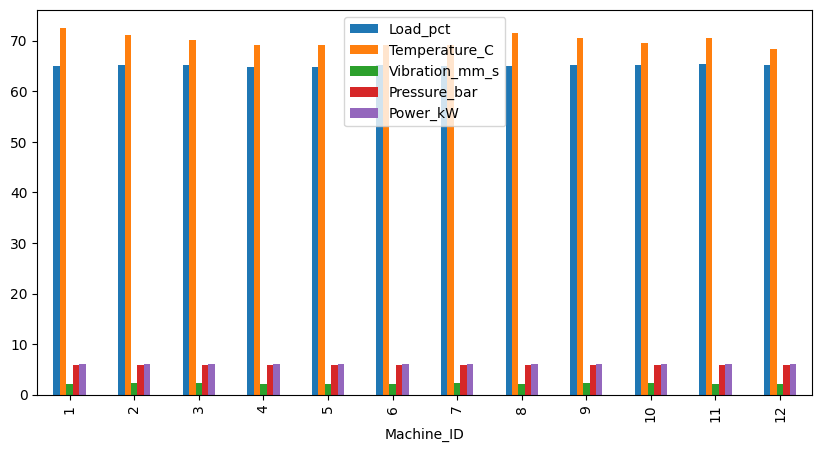

In [28]:
df.groupby('Machine_ID')[sensor_col].mean().plot(kind='bar',figsize=(10,5))

<Axes: xlabel='Machine_ID'>

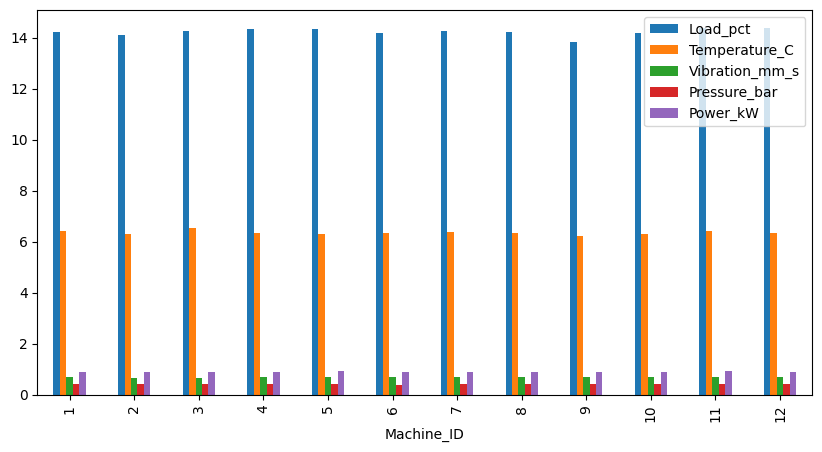

In [29]:
df.groupby('Machine_ID')[sensor_col].std().plot(kind='bar',figsize=(10,5))

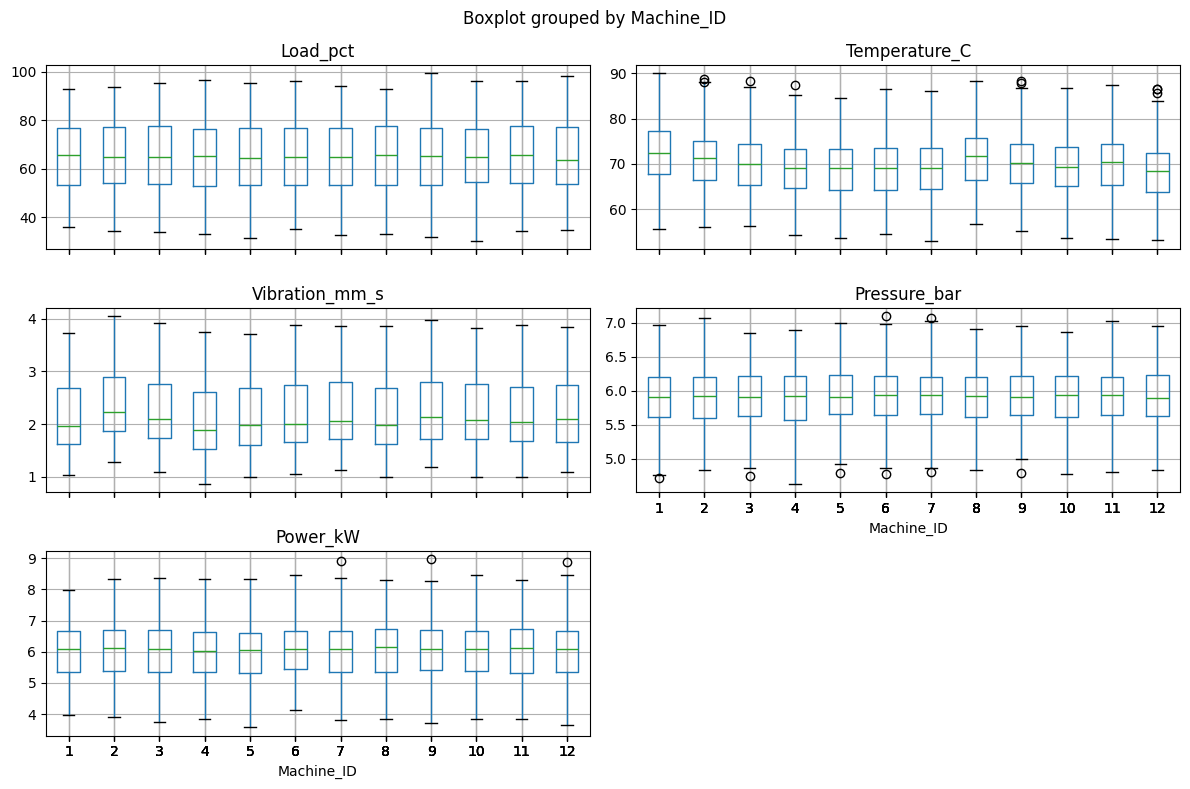

In [30]:
df.boxplot(column=sensor_col,by='Machine_ID',figsize=(12,8),sharey=False)
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

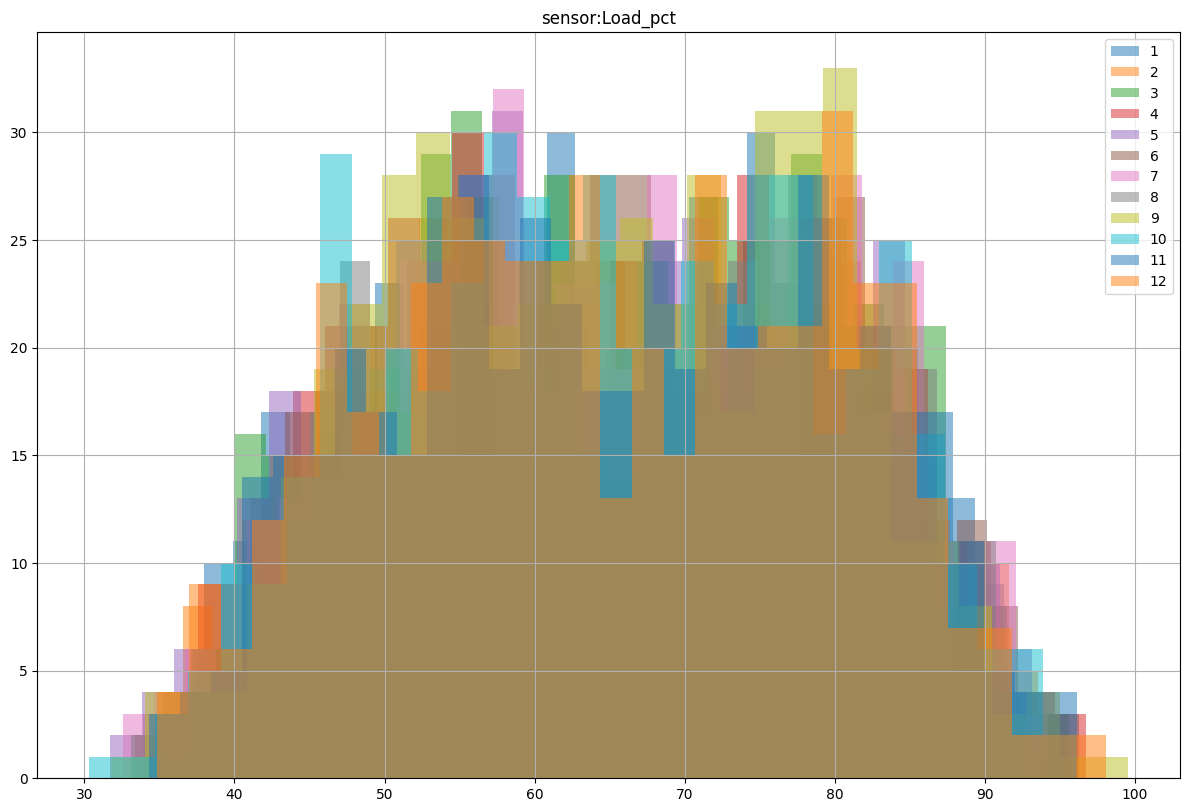

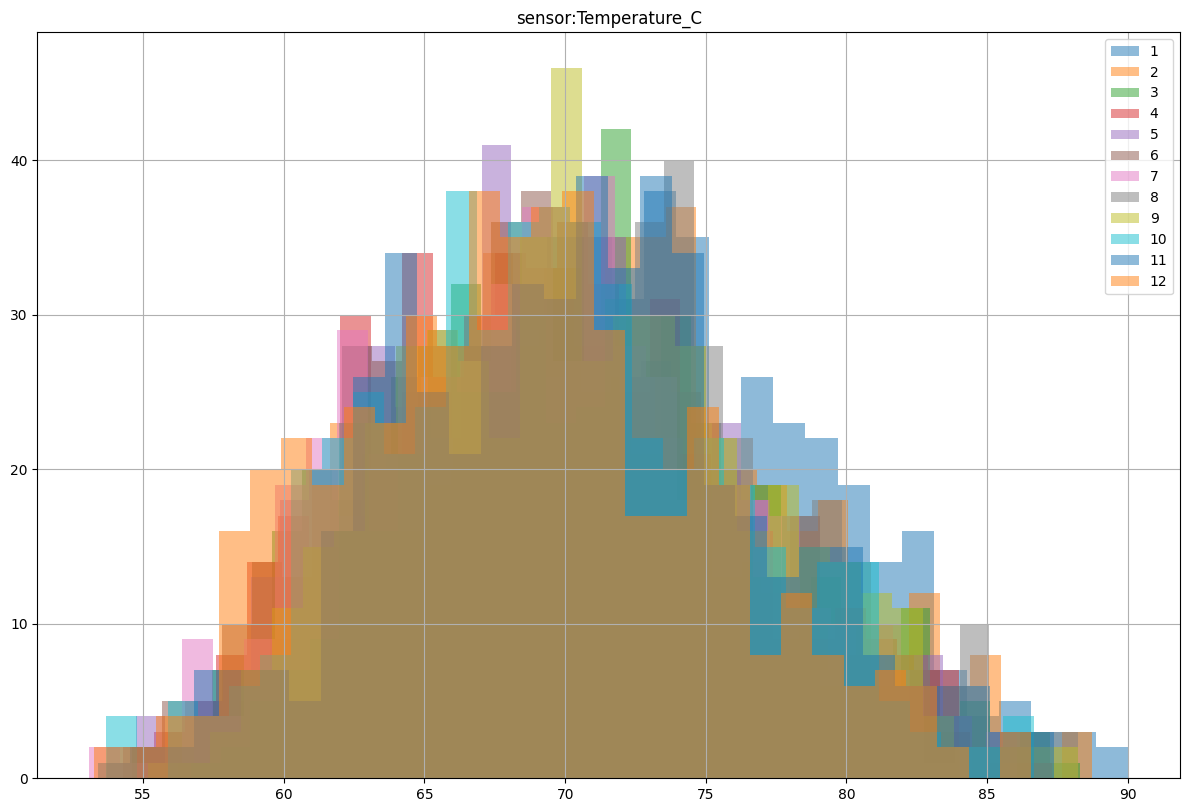

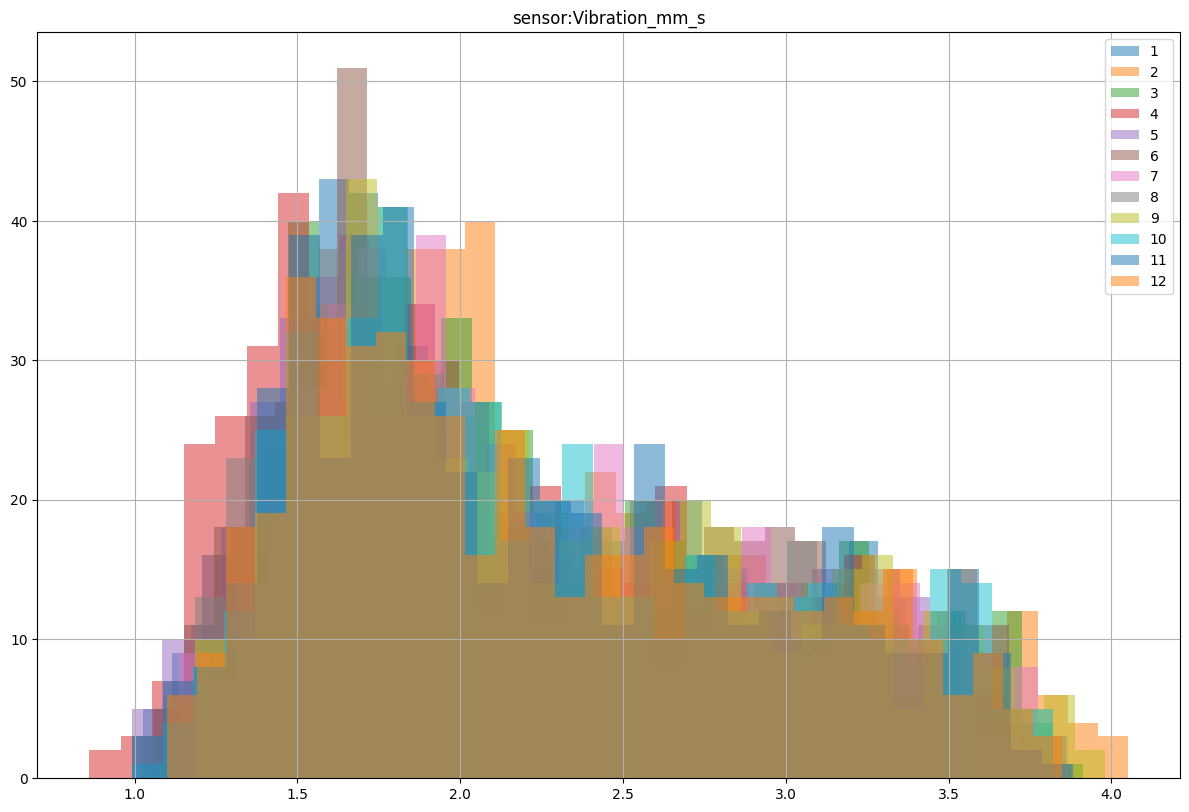

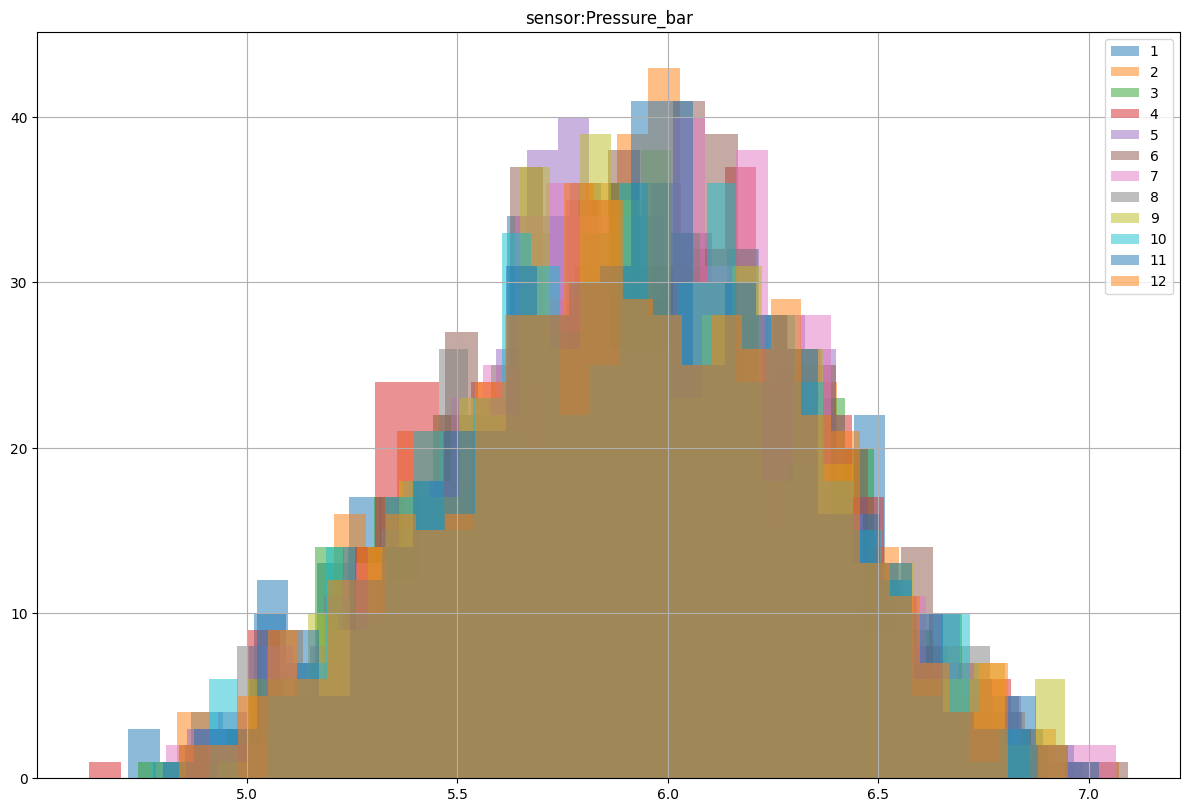

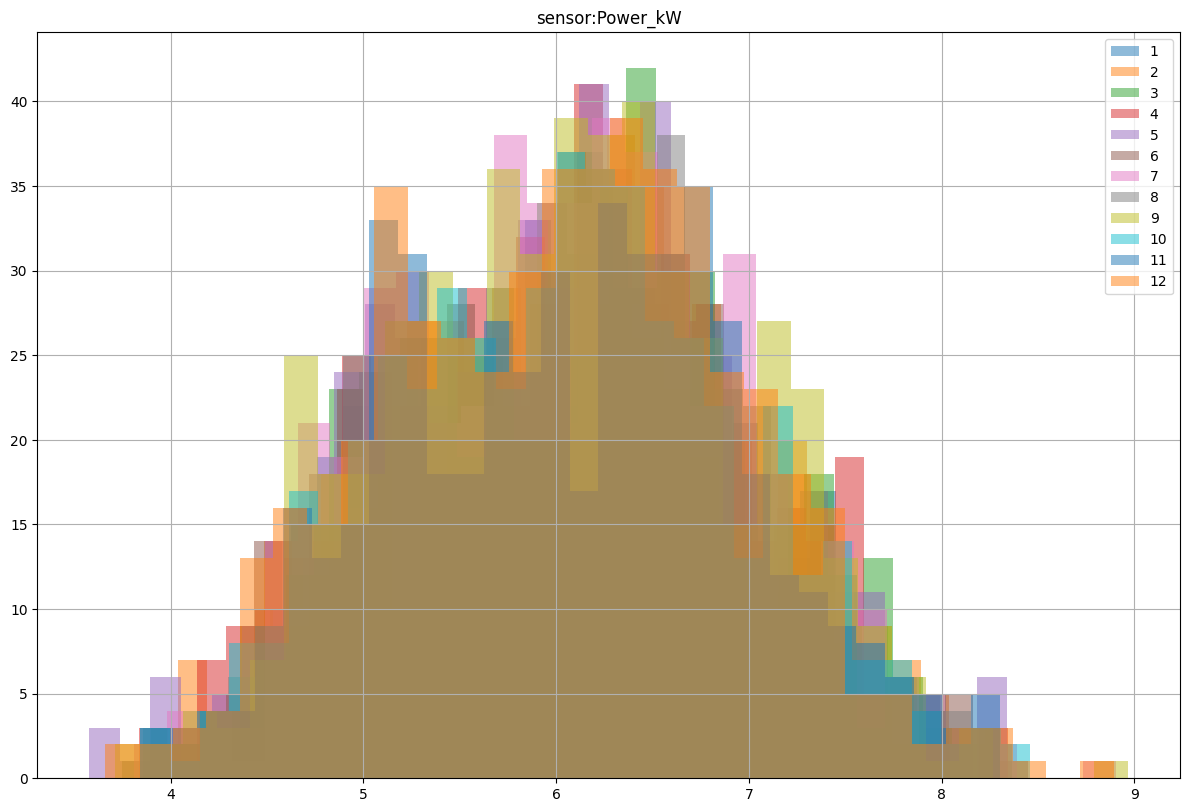

In [31]:
groups_machine=df.groupby('Machine_ID')
plt.figure(figsize=(12,8))

for sensor in sensor_col:
  plt.figure(figsize=(12,8))
  for group_id in groups_machine.groups.keys():
    group=groups_machine.get_group(group_id)
    group[sensor].hist(bins=30,alpha=0.5)
    plt.tight_layout()
    plt.legend(groups_machine.groups.keys())
  plt.title(f"sensor:{sensor}")
  plt.show()

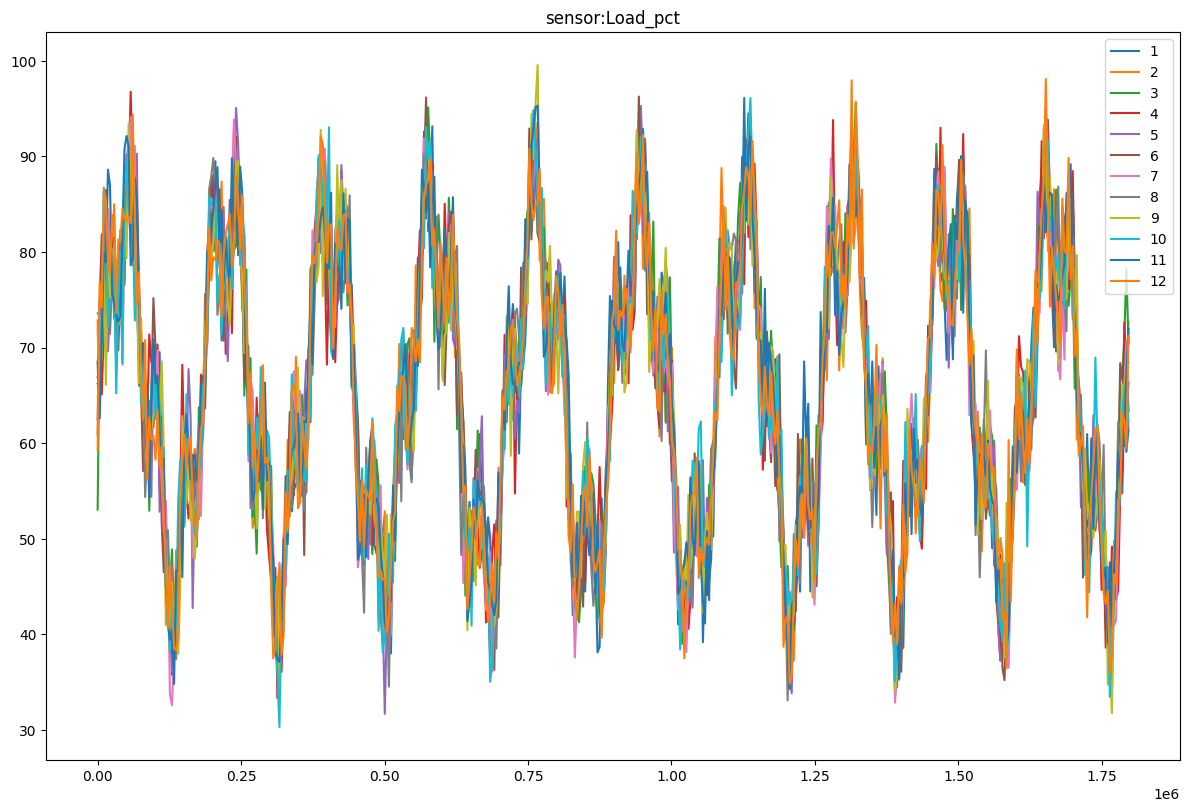

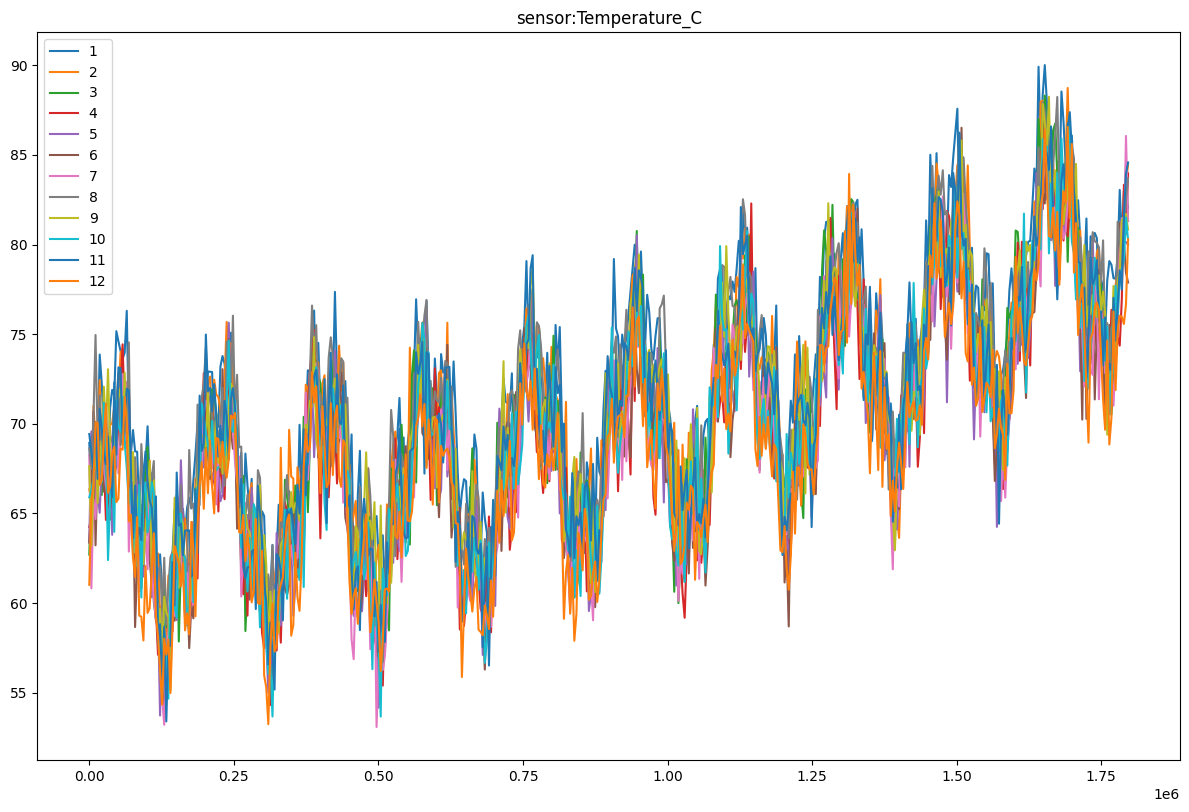

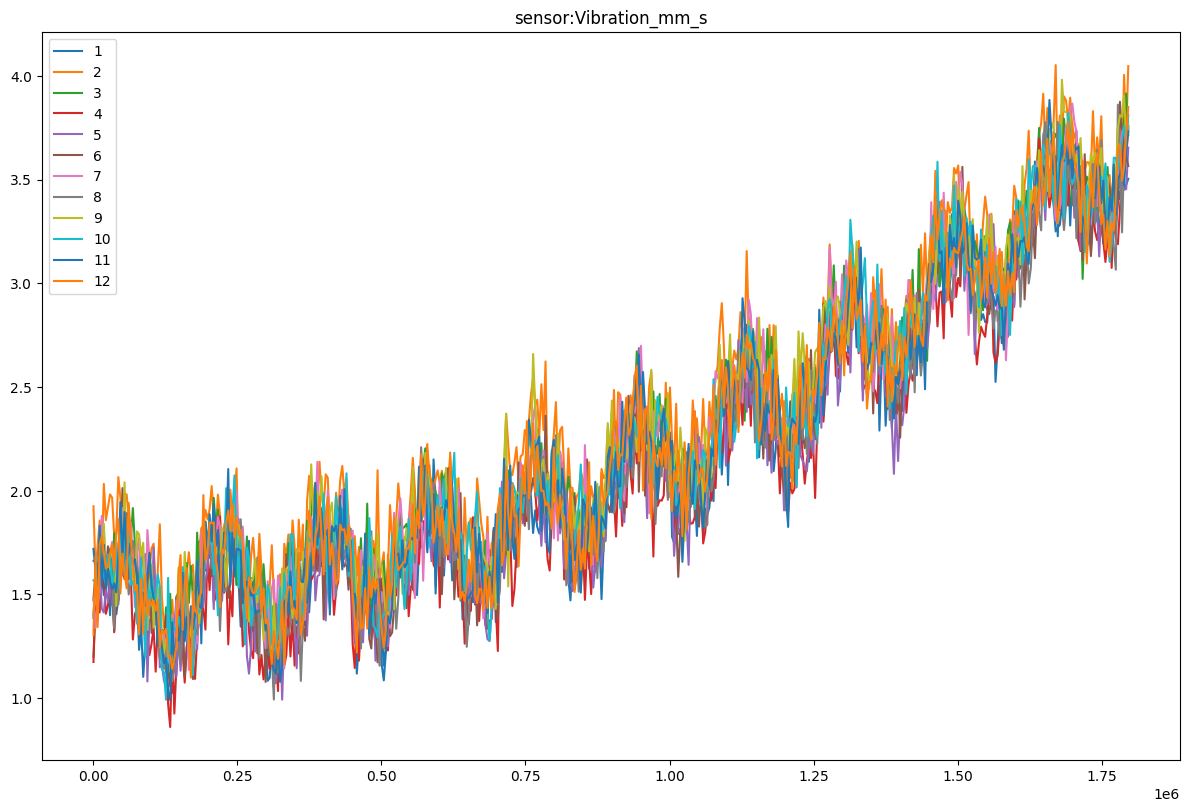

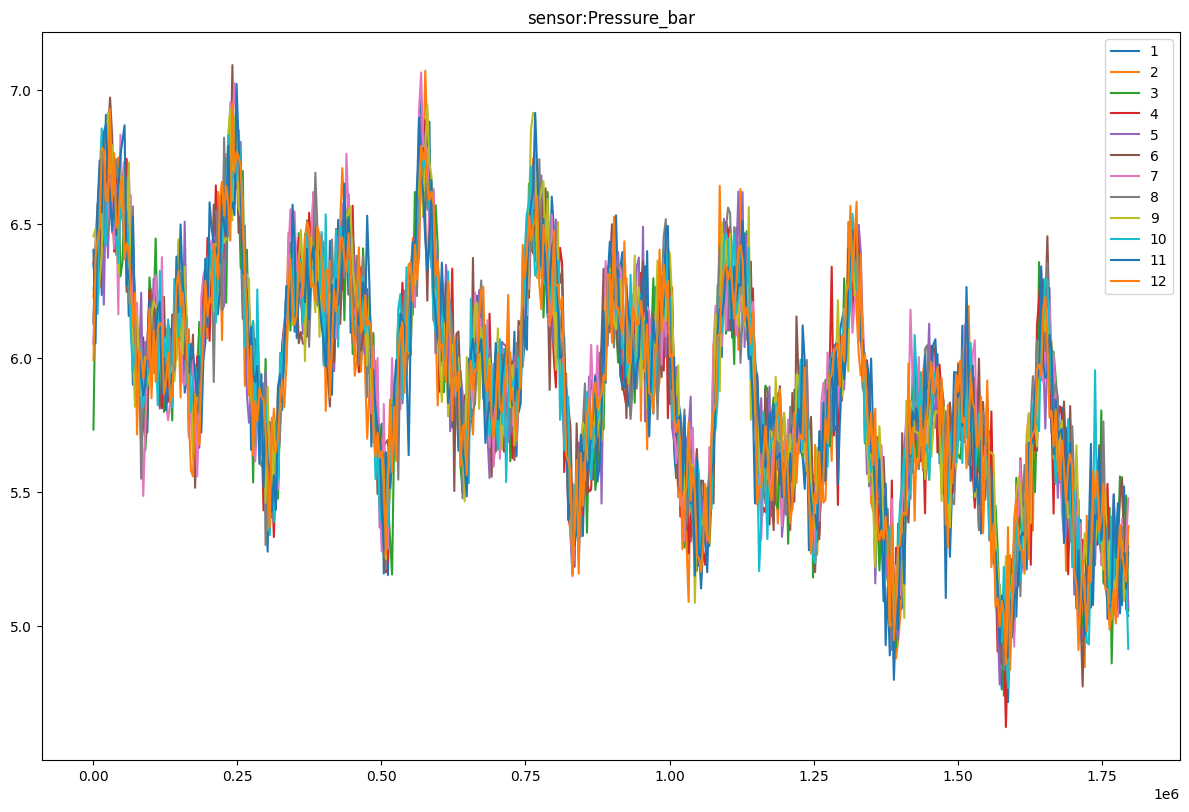

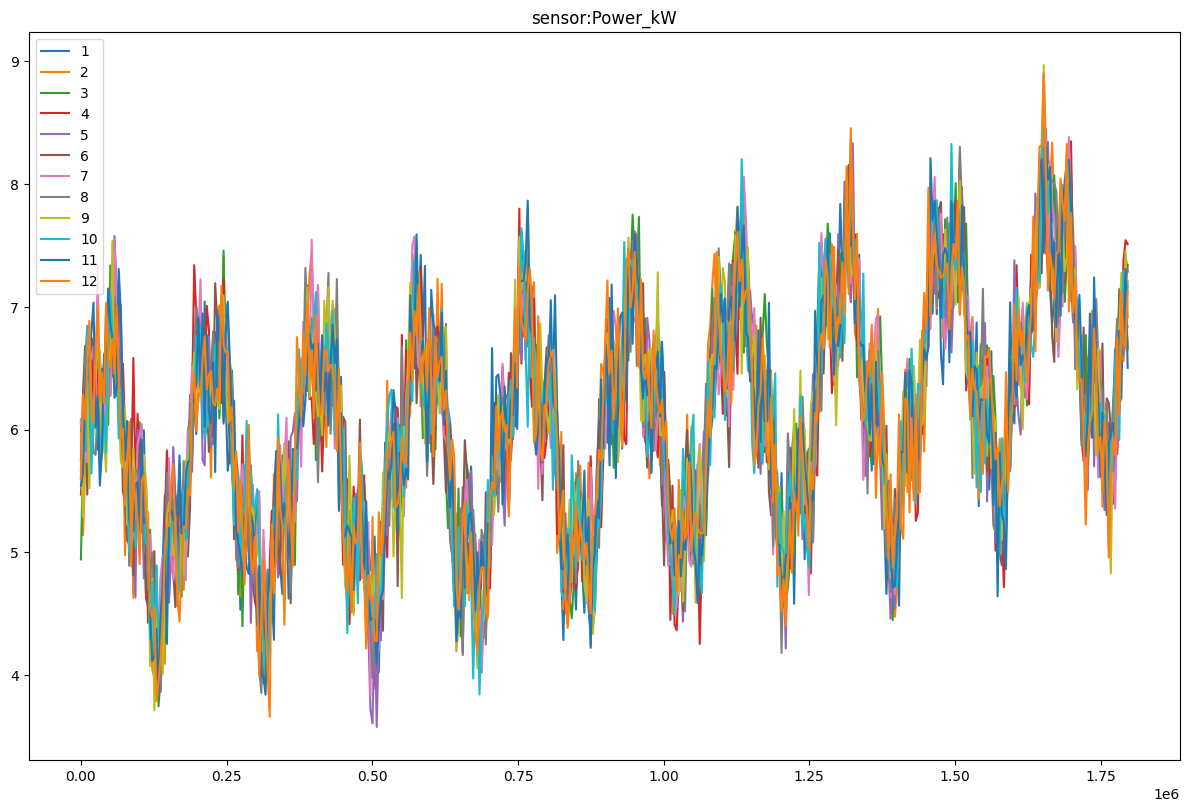

In [32]:
for sensor in sensor_col:
  plt.figure(figsize=(12,8))
  for group_id in groups_machine.groups.keys():
    group=groups_machine.get_group(group_id)
    plt.plot(group['t/s'],group[sensor])
    plt.tight_layout()
    plt.legend(groups_machine.groups.keys())
  plt.title(f"sensor:{sensor}")
  plt.show()


In [33]:
Machines_train=[id for id in range(1,10)]
print(Machines_train)

Machines_test=[id for id in range(10,13)]
print(Machines_test)

[1, 2, 3, 4, 5, 6, 7, 8, 9]
[10, 11, 12]


In [34]:
df.shape

(6000, 11)

In [35]:
X_train=df[df['Machine_ID'].isin(Machines_train)]
X_test =df[df['Machine_ID'].isin(Machines_test)]

In [36]:
X_train['Machine_ID'].unique()

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [37]:
len(X_train[X_train['Machine_ID']==1])

500

In [38]:
X_test['Machine_ID'].unique()

array([10, 11, 12])

In [39]:
X_train.index.is_monotonic_increasing

True

In [52]:
X_train.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       4490, 4491, 4492, 4493, 4494, 4495, 4496, 4497, 4498, 4499],
      dtype='int64', length=4500)

In [46]:
groups_machine=X_train.groupby('Machine_ID')

In [100]:
def prepare_data_array(groups_machine):
  X=[]
  Y=[]
  stride=2
  window_size=20
  horizon_size=10

  for group_id in groups_machine.groups.keys():
    group=groups_machine.get_group(group_id).sort_values('Datetime').reset_index(drop=True)
    for index in range(0,len(group)-window_size-horizon_size+1, stride):
      X.append(group[sensor_col].iloc[index:index+window_size].to_numpy())
      Y.append(group['Health_Score'].iloc[index+window_size:index+window_size+horizon_size].to_numpy())

  X=np.array(X)
  Y=np.array(Y)
  return X,Y

In [101]:
groups_machine=X_train.groupby('Machine_ID')
X_train_array, Y_train_array=prepare_data_array(groups_machine)
print(X_train_array.shape)
print(Y_train_array.shape)

(2124, 20, 5)
(2124, 10)


In [102]:
groups_machine=X_test.groupby('Machine_ID')
X_test_array,Y_test_array=prepare_data_array(groups_machine)
print(X_test_array.shape)
print(Y_test_array.shape)

(708, 20, 5)
(708, 10)


In [103]:
print(Y_test_array)

[[ 98.79237523  98.4581947  100.         ... 100.          98.15642579
   99.9604695 ]
 [100.          98.97564915 100.         ...  99.9604695   99.91524219
  100.        ]
 [100.          99.2879577   99.81753781 ... 100.          98.74440141
   98.86808785]
 ...
 [ 28.30250509  27.81583184  27.96320085 ...  24.90971382  26.14178578
   24.56229827]
 [ 27.96320085  28.49503375  28.23380052 ...  24.56229827  25.16323646
   24.68623113]
 [ 28.23380052  25.75037603  27.24420772 ...  24.68623113  23.88214164
   23.34993143]]


In [104]:
import tensorflow as tf
from tensorflow.keras.layers import LSTM,Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError,MeanAbsoluteError,MeanSquaredError,R2Score


model=Sequential([
    tf.keras.Input(shape=(X_train_array.shape[1],X_train_array.shape[2])),
    LSTM(64),
    Dense(32,activation='relu'),
    Dropout(0.2),
    Dense(Y_train_array.shape[1])
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=[
        RootMeanSquaredError(name='RMSE'),
        MeanAbsoluteError(name='MSE'),
        MeanSquaredError(name='MAE'),
        R2Score(name='R2')]
)

history=model.fit(
    X_train_array,
    Y_train_array,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - MAE: 5714.2285 - MSE: 72.1946 - R2: -10.4717 - RMSE: 75.5925 - loss: 5714.2285 - val_MAE: 4666.6929 - val_MSE: 64.6571 - val_R2: -8.7432 - val_RMSE: 68.3132 - val_loss: 4666.6929
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - MAE: 4253.5093 - MSE: 60.8652 - R2: -7.5446 - RMSE: 65.2189 - loss: 4253.5093 - val_MAE: 2787.5835 - val_MSE: 47.7400 - val_R2: -4.8266 - val_RMSE: 52.7976 - val_loss: 2787.5835
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - MAE: 2197.0278 - MSE: 41.1860 - R2: -3.4186 - RMSE: 46.8725 - loss: 2197.0278 - val_MAE: 1068.0234 - val_MSE: 28.0778 - val_R2: -1.2356 - val_RMSE: 32.6806 - val_loss: 1068.0234
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - MAE: 907.6018 - MSE: 25.6011 - R2: -0.8261 - RMSE: 30.1264 - loss: 907.6018 - val_MAE: 534.5687 - val_MSE: 19.8597 - val_R2: -0.1162 - val_RMSE: 23.1207 - val_loss: 534.5687
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - MAE: 677.6384 - MSE: 

In [105]:
history.history.keys()

dict_keys(['MAE', 'MSE', 'R2', 'RMSE', 'loss', 'val_MAE', 'val_MSE', 'val_R2', 'val_RMSE', 'val_loss'])

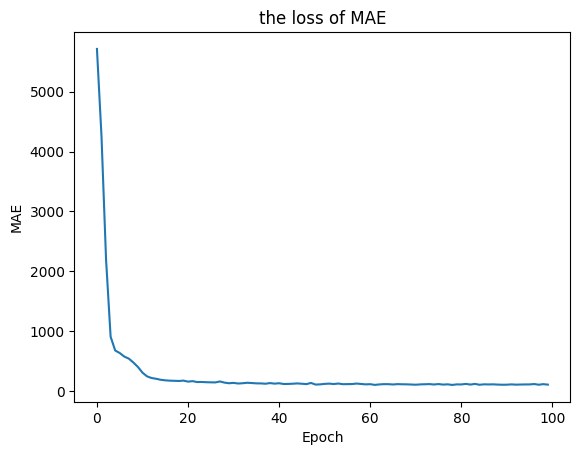

MAE:106.4310531616211


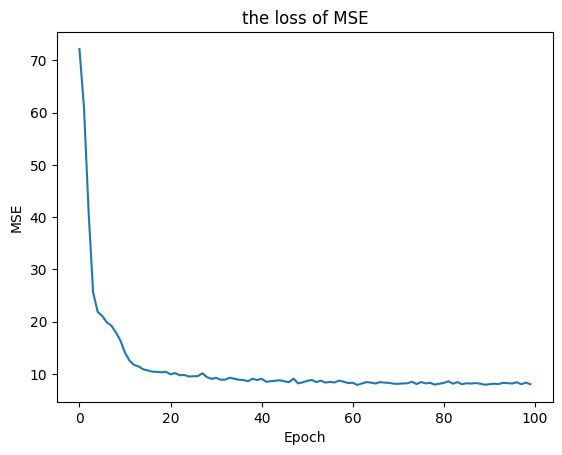

MSE:8.01189136505127


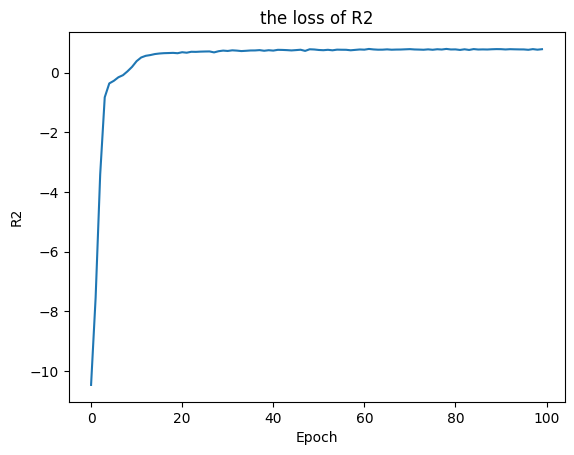

R2:0.7863622903823853


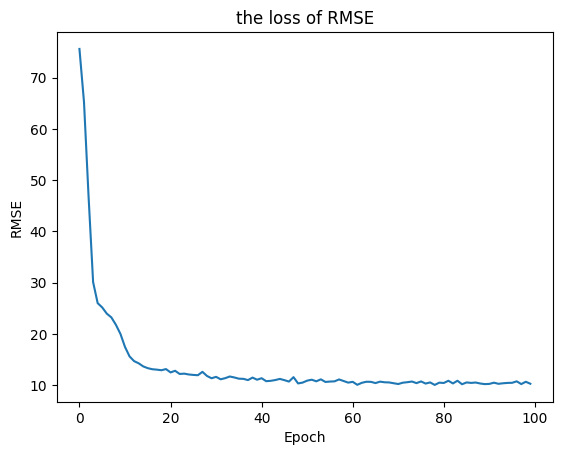

RMSE:10.316542625427246


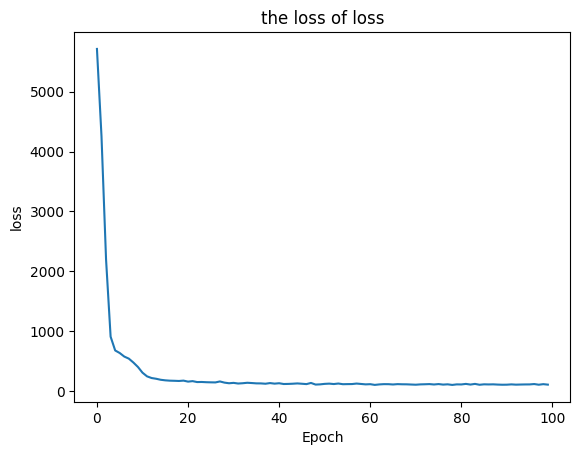

loss:106.4310531616211


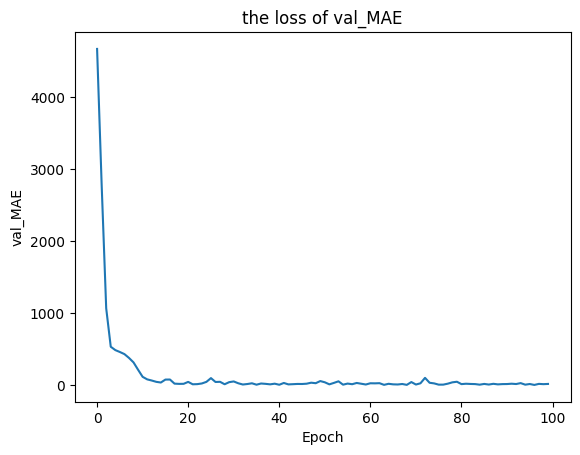

val_MAE:18.39884376525879


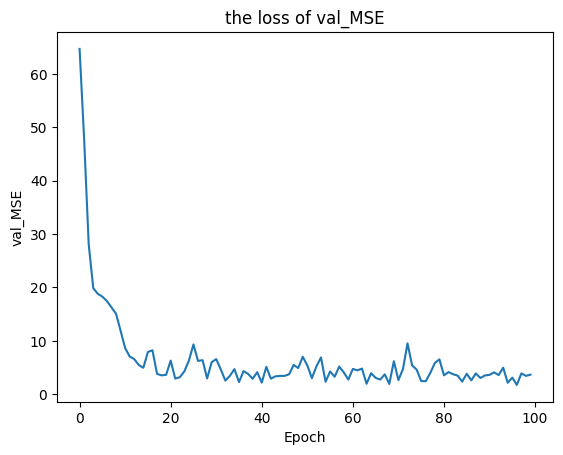

val_MSE:3.670783042907715


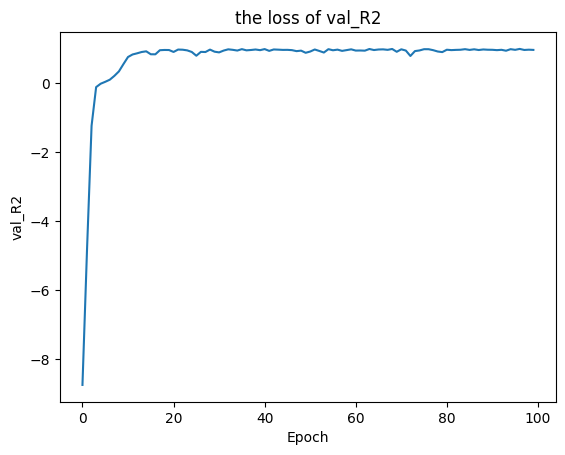

val_R2:0.9615627527236938


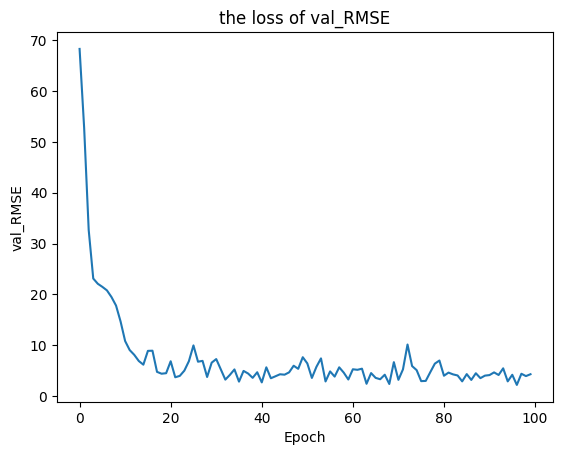

val_RMSE:4.289387226104736


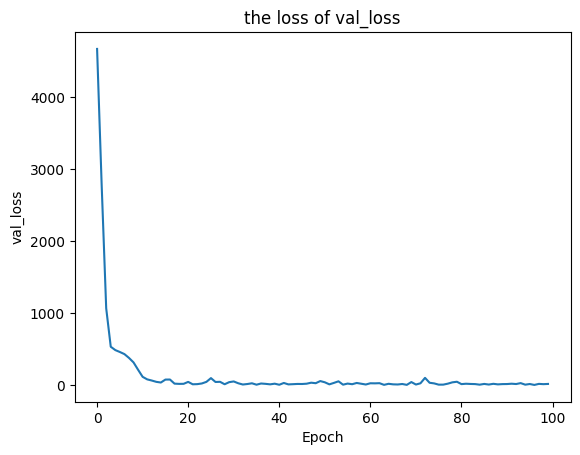

val_loss:18.39884376525879


In [106]:
for key, value in history.history.items():
  plt.figure()
  plt.plot(value)
  plt.title(f"the loss of {key}")
  plt.xlabel('Epoch')
  plt.ylabel(key)
  plt.show()
  print(f"{key}:{value[-1]}")

In [107]:
Y_pred_array=model.predict(X_test_array)


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [108]:
evaluation_metrics=model.evaluate(X_test_array,Y_test_array,return_dict=True)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - MAE: 8.4919 - MSE: 2.3659 - R2: 0.9829 - RMSE: 2.9141 - loss: 8.4919 


In [109]:
Y_pred_array.shape

(708, 10)

In [110]:
Y_test_array.shape

(708, 10)

In [111]:
error=Y_pred_array-Y_test_array

In [112]:
error.shape

(708, 10)

<Axes: >

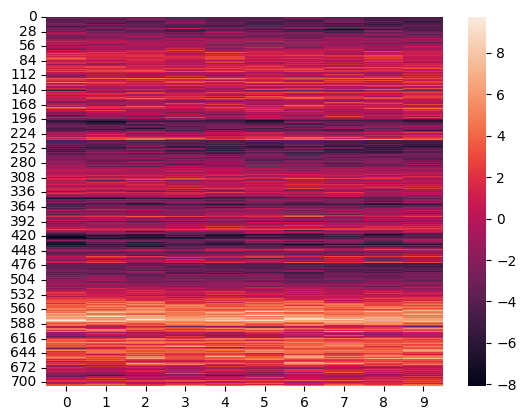

In [113]:
import seaborn as sns
sns.heatmap(error)